# Reproducing the CYCLOPS experiments

This notebook runs every experiment for CYCLOPS (Cyclostationary Profiling
via Coprime Sampling) and generates a PDF, together with a PNG, for every
figure and table it produces, by calling the scripts in this directory;
none of the results here are separately re-derived.

This notebook is assumed to sit in `code/`, alongside every `.py` file it
calls, all within one flat directory, so no `PYTHONPATH` or `sys.path`
configuration is required.

Most cells run in seconds. The S3CA comparison cell takes several minutes,
since `dense_ssca`, the expensive step, is run once per record length as
the ground-truth reference against which S3CA itself is checked. The full
rate and modulation sweep (K = 8 to 200, four modulations, twenty trials
each) is the other slow cell.

Wall-clock timings depend on the machine on which this notebook runs and
on background load, so run-to-run variance in the cost figure and the
S3CA comparison is to be expected even with identical inputs. Recovery
rates, profile errors, and the qualitative shape of every result should
reproduce closely, since every sweep uses fixed seeds; absolute
millisecond figures are illustrative rather than exact, and should be
re-measured on an otherwise idle machine before being relied upon.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

## Exact decimation folding

Verifies the folding identity numerically against direct zero-padded evaluation.

In [2]:
%run fold_core.py

folding identity: max relative error over all N=4096 bins = 3.064e-15
folding identity verified to float precision.



## CRT recombination sanity check

A minimal check that the Chinese remainder theorem recombination recovers exact
bins from exact residues, before any noise or candidate-search logic is involved.

In [3]:
%run coprime.py

CRT recombination verified on exact residues, all cases correct.


## Storage requirement

Every sample position the estimator reads is fixed in advance by the
decimation rates, the lag set, and the readout block length, so a receiver
selecting samples as it acquires never needs to hold the full record. This
is verified here both by counting the required positions and by
overwriting every other sample with NaN, which would poison the result if
anything outside the retained set were read.

In [4]:
%run test_sparse_storage.py

=== distinct sample positions required ===
         N  retained   % of N  closed form
     65280      7418   11.36%         7673
    261632     11107    4.25%        11257
   1047552     18326    1.75%        18425
   4192256     32690    0.78%        32761

  (each 4x in N multiplies storage by ~2x, not 4x: O(sqrt(N)+B))

=== recovery with all non-retained samples set to NaN ===
  N=65280, QPSK sps=24, 15 dB: 10/10 correct
  (any read outside the retained set would propagate NaN and fail)


## Fundamental recovery, profile accuracy, and cost

Single-signal recovery rate across four symbol rates, the degenerate-branch recovery
guarantee, profile-magnitude accuracy vs. readout block length, and wall-clock cost
vs. record length (generates and displays a PDF figure).

In [5]:
%run test_coprime_correctness.py

=== single-signal correctness ===
  sps= 24  alpha0=0.04167  recovery=1.00
  sps= 30  alpha0=0.03333  recovery=0.97
  sps= 40  alpha0=0.02500  recovery=1.00
  sps= 50  alpha0=0.02000  recovery=0.97

=== degenerate-branch recovery ===
  q_true is divisible by exactly one of M1=255, M2=256 for each rate below
  sps= 15  degenerate branch=M2  recovery=0.47
  sps= 16  degenerate branch=M1  recovery=0.57
  sps= 32  degenerate branch=M1  recovery=1.00
  sps= 51  degenerate branch=M2  recovery=1.00

=== a single (non-coprime) decimation under the same degeneracy: fails outright ===
  uses two_stage_alpha0 (twostage.py), the single-decimation pipeline with
  its own coarse-block disambiguation -- not the coprime construction --
  so that the comparison is against a complete competing pipeline, not a
  single unverified gate check.
  sps=16: single-decimation recovery = 0.00 (expected to fail outright under this exact degeneracy)


In [6]:
%run test_profile_accuracy.py

B=  256  mean relative profile error=0.186  (n=40 trials)
B=  512  mean relative profile error=0.124  (n=40 trials)
B= 1024  mean relative profile error=0.100  (n=40 trials)
B= 2048  mean relative profile error=0.068  (n=40 trials)
B= 4096  mean relative profile error=0.043  (n=40 trials)


In [7]:
# This cell repeats the full N=4,192,256 point, which takes noticeably
# longer than the others.
%run test_cost_and_profile.py

         N     (M1,M2)  baseline(ms)  location(ms)  readout(ms)  total(ms)  speedup
     65280   (255,256)          4.54         10.21         0.57      10.79      0.4
    261632   (511,512)         41.75         11.97         0.60      12.57      3.3
   1047552 (1023,1024)        152.23         22.38         0.67      23.05      6.6
   4192256 (2047,2048)       1049.34         33.34         0.58      33.92     30.9


fig1_cost written
  N=    65280  baseline=    6.17 ms  total=  11.24 ms  speedup=0.5x
  N=   261632  baseline=   40.26 ms  total=  12.21 ms  speedup=3.3x
  N=  1047552  baseline=  160.40 ms  total=  22.23 ms  speedup=7.2x
  N=  4192256  baseline= 1038.43 ms  total=  32.56 ms  speedup=31.9x


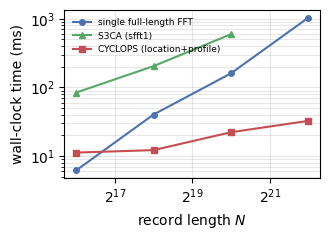

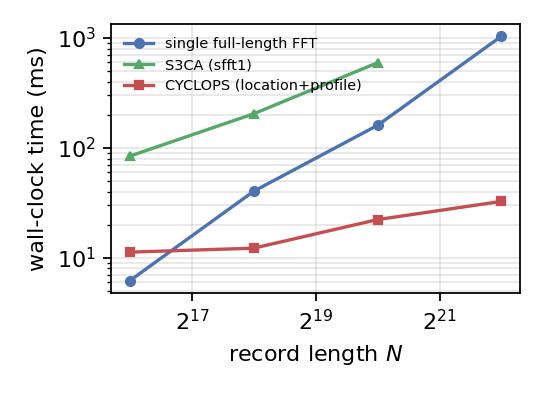

<Figure size 640x480 with 0 Axes>

In [8]:
%run fig_gen_fig1_cost.py
from IPython.display import Image, display
display(Image(filename="fig1_cost.png"))

## Comparison against S3CA

Runs the S3CA implementation (`s3ca.py`, `sfft1` backend only) against the coprime
estimator on the same signals, extracting the alpha profile from each method's native
output via the same per-channel/per-bin lookup, then generates and displays a PDF
table of the comparison.

In [9]:
%run compare_s3ca.py


=== N=65280 (0.07M samples), Np=32, kappa=8 ===
  timing (ms): S3CA dense=110.9  S3CA sfft1=80.3  our coprime=11.1
  our coprime vs S3CA sfft1 (same task, alpha profile only): 7.2x faster
  alpha_hat correct: True
    m    dense_ssca   s3ca(sfft1)   rel.err
    1       86711.1       89006.7     0.026
    2       51035.2       52671.7     0.032
    3       26123.9       28019.4     0.073
    4       17979.0       17392.3     0.033
    5       13916.7       13639.4     0.020

=== N=261632 (0.26M samples), Np=32, kappa=8 ===
  timing (ms): S3CA dense=532.0  S3CA sfft1=207.6  our coprime=14.9
  our coprime vs S3CA sfft1 (same task, alpha profile only): 13.9x faster
  alpha_hat correct: True
    m    dense_ssca   s3ca(sfft1)   rel.err
    1      330745.7      339851.0     0.028
    2      194797.5      204919.1     0.052
    3      109443.4      116435.5     0.064
    4       69684.7       70244.8     0.008
    5       54198.8       46857.0     0.135

=== N=1047552 (1.05M samples), Np=32, 

table_s3ca_comparison written
  65,280  101.1  74.6  11.4  6.5x
  261,632  527.4  196.4  14.1  14.0x
  1,047,552  2229.1  606.8  24.0  25.3x


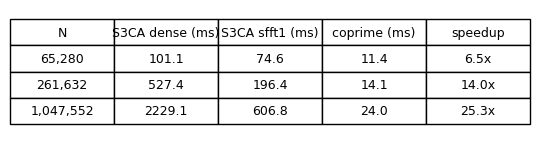

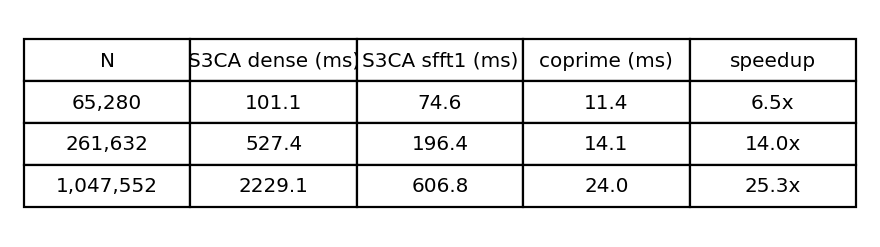

<Figure size 640x480 with 0 Axes>

In [10]:
%run gen_table_s3ca.py
from IPython.display import Image, display
display(Image(filename="table_s3ca_comparison.png"))

## Broadband combs: DSSS validation

Builds a genuine short-code DSSS-BPSK signal (fixed length-31 maximal-length
spreading sequence) and runs the full pipeline including the harmonic-order
resolution step, then generates and displays a PDF figure of the dense vs.
coprime-estimator alpha profile.

In [11]:
%run test_dsss.py

chip period = 4 samples, symbol (code) period = 124 samples
data rate alpha0 = 0.008065, chip rate = 0.250

locked onto data rate: 20/20
locked onto chip rate: 0/20
(coprime_alpha0 now applies divisor-consistency resolution -- see resolve_harmonic_order in coprime.py -- which prefers the smaller of two genuine cyclic features related by an integer ratio; the chip rate here is exactly 31x the data rate, so it is consistently resolved down to the data rate rather than reported directly)

representative trial: locked onto alpha0=0.008064516129032258
  m=1  alpha=0.00806  P_full=0.3836
  m=2  alpha=0.01613  P_full=0.4079
  m=3  alpha=0.02419  P_full=0.4299
  m=4  alpha=0.03226  P_full=0.4046
  m=5  alpha=0.04032  P_full=0.4608


fundamental recovery: 20/20
mean relative profile error across all 18 harmonics: 0.003
fig3_dsss_profile written


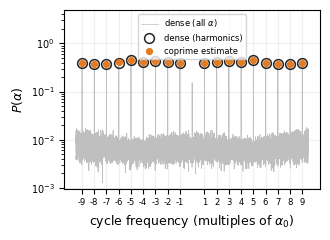

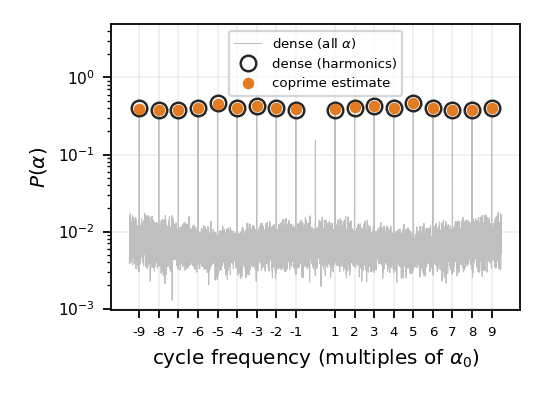

<Figure size 640x480 with 0 Axes>

In [12]:
%run fig_gen_fig2_dsss.py
from IPython.display import Image, display
display(Image(filename="fig3_dsss_profile.png"))

## Sensitivity to SNR, carrier offset, and a second signal

Recovery vs. SNR at fixed verification block length, recovery vs. block length across
SNRs, carrier-offset invariance, and the two-signal spurious-lock experiment, then
generates and displays a PDF figure of the SNR and two-signal results.

In [13]:
%run test_snr_and_bverify.py

=== recovery vs. SNR, B_verify=1024 fixed ===
  SNR= 10 dB  recovery=0.98
  SNR=  6 dB  recovery=0.98
  SNR=  4 dB  recovery=0.80
  SNR=  2 dB  recovery=0.25
  SNR=  0 dB  recovery=0.00
  SNR= -2 dB  recovery=0.00

=== recovery vs. B_verify, insensitivity check ===
  B_verify=   16  15dB=0.98  10dB=0.92  8dB=0.63
  B_verify=   32  15dB=0.93  10dB=0.73  8dB=0.52
  B_verify=   64  15dB=0.98  10dB=0.93  8dB=0.82
  B_verify=  128  15dB=0.97  10dB=0.98  8dB=0.95
  B_verify=  256  15dB=0.97  10dB=0.95  8dB=0.92
  B_verify=  512  15dB=0.95  10dB=0.98  8dB=0.97
  B_verify= 1024  15dB=1.00  10dB=1.00  8dB=0.98
  B_verify= 2048  15dB=1.00  10dB=1.00  8dB=1.00
  B_verify= 4096  15dB=1.00  10dB=1.00  8dB=1.00


In [14]:
%run test_carrier_sweep.py

     fc  recovery mean rel err  profile err  m used
  -0.49      0.95      0.0e+00        0.029     2.2
  -0.40      1.00      0.0e+00        0.029     2.5
  -0.25      0.95      0.0e+00        0.031     2.2
   0.00      0.95      0.0e+00        0.027     2.4
   0.25      0.95      0.0e+00        0.026     2.3
   0.40      1.00      0.0e+00        0.029     2.1
   0.49      0.95      0.0e+00        0.029     2.5


In [15]:
%run test_multisignal.py

true rates: a0_a=0.04167 (sps=24), a0_b=0.02500 (sps=40)

power ratio b/a=1.0:  correct=29/60  spurious=8/60  no-detection=23/60
power ratio b/a=0.3:  correct=60/60  spurious=0/60  no-detection=0/60
power ratio b/a=0.1:  correct=60/60  spurious=0/60  no-detection=0/60


fig2_reliability written


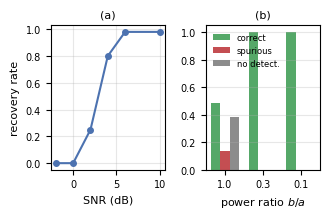

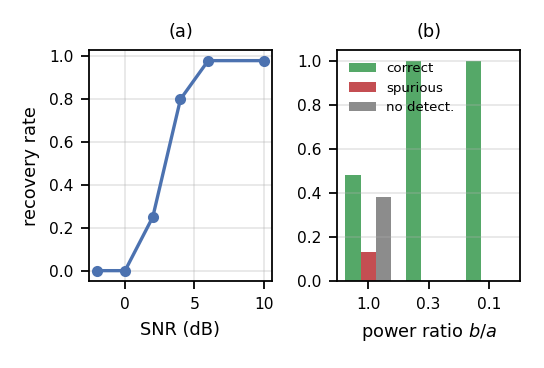

<Figure size 640x480 with 0 Axes>

In [16]:
%run fig_gen_fig2_reliability.py
from IPython.display import Image, display
display(Image(filename="fig2_reliability.png"))

## Rate, modulation, and off-grid cycle frequencies

Cross-modulation table at three representative rates, the finer rate sweep across
K = 8-200 for all four modulations (rendered as a PDF table), and recovery outcome vs.
sub-bin offset from the nearest native bin for a symbol rate that does not land exactly
on a native bin (also rendered as a PDF table).

In [17]:
%run test_cross_modulation.py

Mod       Rate  recoverymean rel err  profile err  m used
BPSK      0.10      0.25   0.0e+00        0.060     1.0
QPSK      0.10      0.50   0.0e+00        0.030     1.0
8PSK      0.10      0.35   0.0e+00        0.033     1.0
16QAM     0.10      0.30   0.0e+00        0.027     1.0
BPSK      0.05      1.00   0.0e+00        0.067     2.3
QPSK      0.05      1.00   0.0e+00        0.035     2.1
8PSK      0.05      1.00   0.0e+00        0.033     2.1
16QAM     0.05      1.00   0.0e+00        0.068     2.3
BPSK      0.02      1.00   3.1e-04        0.353     1.0
QPSK      0.02      0.80   1.2e-01        0.295     1.0
8PSK      0.02      0.95   5.0e-02        0.315     1.0
16QAM     0.02      0.60   1.5e+00        0.328     1.0


In [18]:
# Full sweep, K = 8 to 200, four modulations, twenty trials each: the
# second-slowest cell in this notebook after the S3CA comparison above.
%run test_rate_reliability.py

  sps    rate     BPSK     QPSK     8PSK    16QAM
    8  0.1250  -- skipped (degenerate residue for this pair) --
   10  0.1000     0.65     0.45     0.40     0.40
   12  0.0833     0.95     0.95     0.90     0.85
   16  0.0625  -- skipped (degenerate residue for this pair) --
   20  0.0500     1.00     1.00     1.00     1.00
   24  0.0417     1.00     1.00     1.00     1.00
   30  0.0333     0.90     1.00     0.95     1.00
   40  0.0250     1.00     1.00     1.00     1.00
   50  0.0200     1.00     1.00     0.95     0.85
   64  0.0156  -- skipped (degenerate residue for this pair) --
   80  0.0125     1.00     1.00     0.95     1.00
  100  0.0100     1.00     1.00     1.00     0.60
  130  0.0077     0.90     1.00     0.95     0.20
  160  0.0063     0.05     0.05     0.05     0.05
  200  0.0050     0.00     0.10     0.05     0.00


table_rate_reliability written
  10  0.1000  0.65  0.45  0.40  0.40
  12  0.0833  0.95  0.95  0.90  0.85
  20  0.0500  1.00  1.00  1.00  1.00
  24  0.0417  1.00  1.00  1.00  1.00
  30  0.0333  0.90  1.00  0.95  1.00
  40  0.0250  1.00  1.00  1.00  1.00
  50  0.0200  1.00  1.00  0.95  0.85
  80  0.0125  1.00  1.00  0.95  1.00
  100  0.0100  1.00  1.00  1.00  0.60
  130  0.0077  0.90  1.00  0.95  0.20
  160  0.0063  0.05  0.05  0.05  0.05
  200  0.0050  0.00  0.10  0.05  0.00


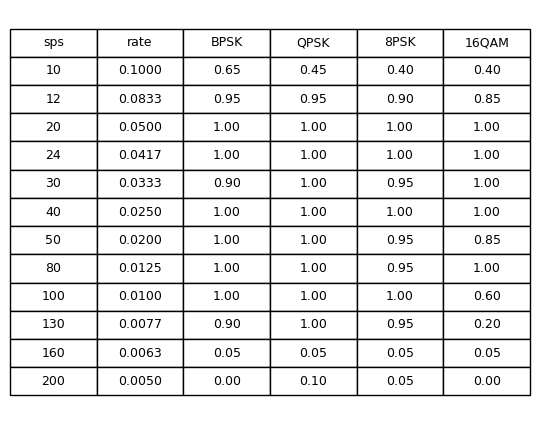

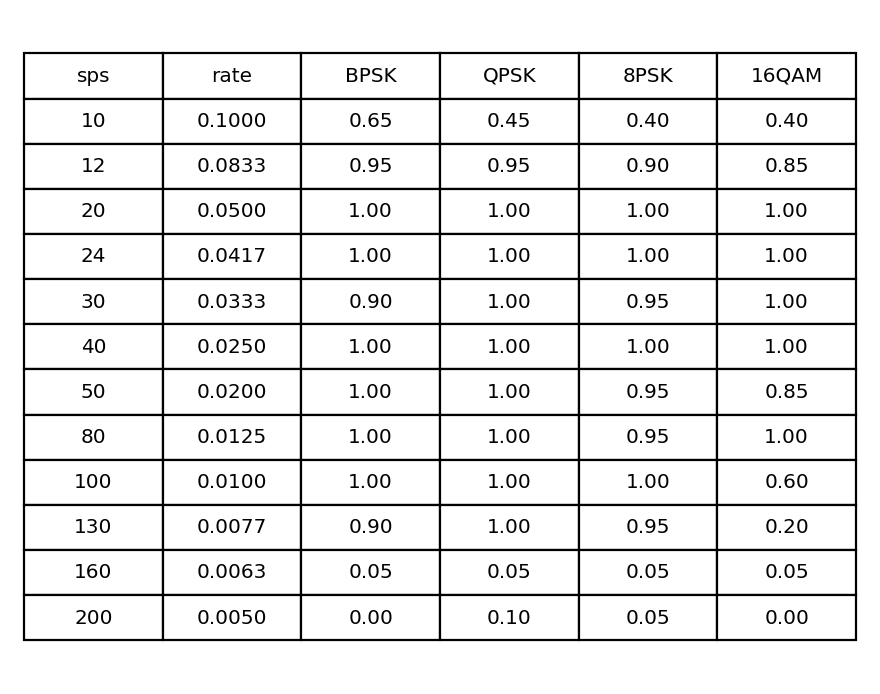

<Figure size 640x480 with 0 Axes>

In [19]:
%run gen_table_rate.py
from IPython.display import Image, display
display(Image(filename="table_rate_reliability.png"))

### Lag-set structural nulls

A lag contributes zero cyclic signal whenever it is smaller than
$\gcd(D, K)$ for a branch's decimation stride $D$, an exact structural
null, distinct from the dilution-by-noise mechanism above, that can
silence the entire fixed lag set on one branch for symbol periods sharing
large factors with that branch's stride.

In [20]:
%run test_lag_gcd.py

=== gcd(D_i, sps) risk table ===
  sps=  7  gcd(D1,sps)=  1  gcd(D2,sps)=  1
  sps=  8  gcd(D1,sps)=  8  gcd(D2,sps)=  1
  sps=  9  gcd(D1,sps)=  1  gcd(D2,sps)=  3
  sps= 11  gcd(D1,sps)=  1  gcd(D2,sps)=  1
  sps= 12  gcd(D1,sps)=  4  gcd(D2,sps)=  3
  sps= 23  gcd(D1,sps)=  1  gcd(D2,sps)=  1
  sps= 24  gcd(D1,sps)=  8  gcd(D2,sps)=  3
  sps= 48  gcd(D1,sps)= 16  gcd(D2,sps)=  3
  sps= 96  gcd(D1,sps)= 32  gcd(D2,sps)=  3  <-- one branch fully dead across the whole lag set

=== per-lag magnitude, branch 1, sps=24 (gcd=8) ===
  tau= 4: 0.003  (dead: tau < gcd)
  tau= 8: 0.336
  tau=12: 0.337
  tau=16: 0.335
  tau=20: 0.335
  tau=24: 0.050

=== per-lag magnitude, branch 1, sps=96 (gcd=32, whole set dead) ===
  tau= 4: 0.003
  tau= 8: 0.003
  tau=12: 0.002
  tau=16: 0.003
  tau=20: 0.003
  tau=24: 0.003

=== per-lag magnitude, branch 2, sps=96 (gcd=3, weakened not dead) ===
  tau= 4: 0.032
  tau= 8: 0.065
  tau=12: 0.120
  tau=16: 0.150
  tau=20: 0.176
  tau=24: 0.226

=== full-pipelin

### Adaptive lag set

A fixed lag set cannot satisfy both bounds across a wide rate range. Scaling
the lags with the symbol period does, and restores recovery at rates where the
fixed set fails at either end.

In [21]:
%run test_adaptive_lags.py

=== usable lag window per branch (EMPTY means no lag can work there) ===
  K=   8  branch1        EMPTY   branch2        [1,8)
  K=  10  branch1       [2,10)   branch2       [5,10)
  K=  12  branch1       [4,12)   branch2       [3,12)
  K=  16  branch1        EMPTY   branch2       [1,16)
  K=  20  branch1       [4,20)   branch2       [5,20)
  K=  24  branch1       [8,24)   branch2       [3,24)
  K=  30  branch1       [2,30)   branch2      [15,30)
  K=  40  branch1       [8,40)   branch2       [5,40)
  K=  50  branch1       [2,50)   branch2       [5,50)
  K=  64  branch1        EMPTY   branch2       [1,64)
  K=  80  branch1      [16,80)   branch2       [5,80)
  K= 100  branch1      [4,100)   branch2      [5,100)
  K= 130  branch1      [2,130)   branch2      [5,130)
  K= 160  branch1     [32,160)   branch2      [5,160)
  K= 200  branch1      [8,200)   branch2      [5,200)

=== recovery: fixed {4,8,...,24} vs adaptive_lags(K), 15 dB ===
    K       set    BPSK    QPSK    8PSK   16QAM
    

In [22]:
%run test_offgrid.py

  delta   exact    wild  no-detect
   0.00    1.00    0.00       0.00
   0.10    1.00    0.00       0.00
   0.20    1.00    0.00       0.00
   0.30    0.98    0.00       0.02
   0.40    0.82    0.05       0.13
   0.45    0.48    0.15       0.37
   0.50    0.27    0.23       0.50


table_offgrid written
  0.00  1.00  0.00  0.00
  0.10  1.00  0.00  0.00
  0.20  1.00  0.00  0.00
  0.30  0.98  0.00  0.02
  0.40  0.82  0.05  0.13
  0.45  0.48  0.15  0.37
  0.50  0.27  0.23  0.50


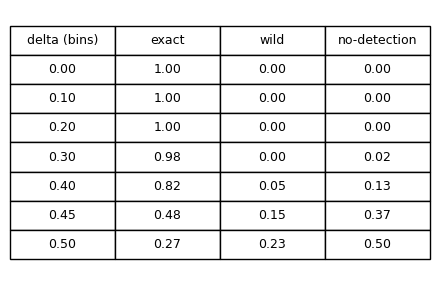

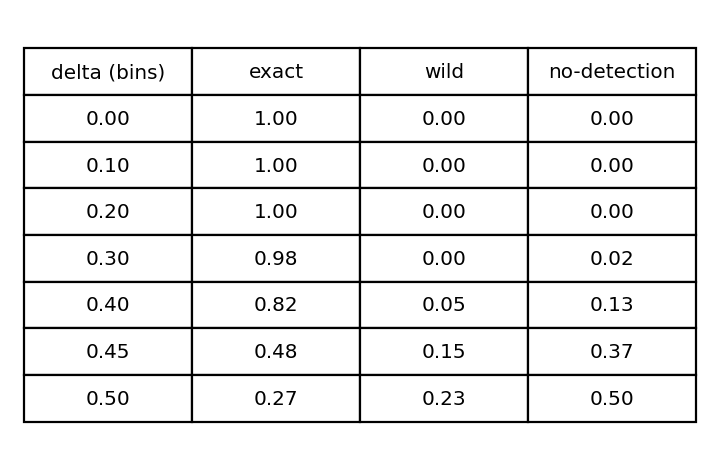

<Figure size 640x480 with 0 Axes>

In [23]:
%run gen_table_offgrid.py
from IPython.display import Image, display
display(Image(filename="table_offgrid.png"))

## Summary

Every `run_*()` function used above (`run_cost_sweep`,
`run_s3ca_comparison`, `run_rate_sweep`, `run_offgrid_sweep`) returns its
results as structured data, so any number printed or plotted above can be
recomputed or reused directly without re-parsing printed text. Every
sweep uses fixed seeds, so exact-recovery-rate figures such as "20/20"
should reproduce exactly on any machine; wall-clock timing figures vary
with the machine and load, as noted at the top of this notebook.